# Error evaluation
In this notebook we evaluate how well our trained ROM performs.

## Imports

In [1]:
import pickle
import numpy as np
import scipy.sparse as sparse
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import interp1d
import scipy.io as io
import pandas as pd
import seaborn as sns

import time
tStart_notebook = time.time()

import sys
sys.path.insert(0, '../../source')
sys.path.insert(0, '../../source/fom')
sys.path.insert(0, '../../source/testing')
sys.path.insert(0, '../../source/methods')
sys.path.insert(0, '../../source/opinf_schemes')

import opinf as opinf
from solvers import lstsq_truncSVD, regularized_least_squares
from fom.Fom import Fom
from matrixSetup.FoodTime import FoodTime

## User settings

In [2]:
savepath = "/storage/nicole/Greenland-OpInf/paper/"
iteration_no = 2050
n_splits = 4

## Helper functions

In [3]:
run -i "rom-helper.py"

## Setup

Load the reduced space

In [4]:
with open(savepath + f"data/reduced-space-{iteration_no}_{1e-2}", "rb") as file:
    training_data, VR, transformer_h, VR_vel, transformer_vel, list_train, __, __, __ = pickle.load(file)

n_para = training_data.shape[0]
nFE = VR.shape[0]
nRB = VR.shape[1]
nRB_vel = VR_vel.shape[1]+1

Decide on testing parameters

In [5]:
list_identifiers = list_train.copy()
list_identifiers_next = list_train.copy()

for j in range(n_splits):
    for i, id in enumerate(list_identifiers[:-1]):
        id_new = int((id + list_identifiers[i+1])/2)
        list_identifiers_next.append(id_new)
    list_identifiers_next.sort()
    list_identifiers = list_identifiers_next.copy()

print(len(list_identifiers))
list_test = list_identifiers
n_para = len(list_identifiers)

257


Load the current ROM

In [6]:
run -i fom-helper.py

In [7]:
ROMq = np.zeros(3, dtype=object)
VRq = np.zeros(3, dtype=object)

for i, threshold in enumerate([1e-0, 1e-1, 1e-2]):

    with open(savepath + f"data/reduced-space-{iteration_no}_{threshold}", "rb") as file:
        __, VRq[i], __, __, __, __, __, __, __ = pickle.load(file)
    
    with open(savepath + f"trained/greedy-step-{iteration_no}-{threshold}", "rb") as file:
        qInferred, __, __ = pickle.load(file)

    fom = StructureHelper()
    matrixhandler = FoodTime(VRq[i], fom, transformer=transformer_h)

    ROMq[i] = matrixhandler.get_reduced_model(qInferred[-1], indices = [*range(VRq[i].shape[1])])

Load the snapshots / test data

In [8]:
run -i "load-snapshots.py"

loaded snapshot 0
loaded snapshot 1
loaded snapshot 2
loaded snapshot 3
loaded snapshot 4
loaded snapshot 5
loaded snapshot 6
loaded snapshot 7
loaded snapshot 8
loaded snapshot 9
loaded snapshot 10
loaded snapshot 11
loaded snapshot 12
loaded snapshot 13
loaded snapshot 14
loaded snapshot 15
loaded snapshot 16
loaded snapshot 17
loaded snapshot 18
loaded snapshot 19
loaded snapshot 20
loaded snapshot 21
loaded snapshot 22
loaded snapshot 23
loaded snapshot 24
loaded snapshot 25
loaded snapshot 26
loaded snapshot 27
loaded snapshot 28
loaded snapshot 29
loaded snapshot 30
loaded snapshot 31
loaded snapshot 32
loaded snapshot 33
loaded snapshot 34
loaded snapshot 35
loaded snapshot 36
loaded snapshot 37
loaded snapshot 38
loaded snapshot 39
loaded snapshot 40
loaded snapshot 41
loaded snapshot 42
loaded snapshot 43
loaded snapshot 44
loaded snapshot 45
loaded snapshot 46
loaded snapshot 47
loaded snapshot 48
loaded snapshot 49
loaded snapshot 50
loaded snapshot 51
loaded snapshot 52
loa

Reformat

In [9]:
test_data = np.zeros(len(list_identifiers), dtype=dict)

for i, id in enumerate(list_identifiers):
    pos = list_identifiers.index(id)

    k_train = np.argmin(np.abs(snapshot_data[i]["grid_t"]-iteration_no))+1
    grid_t = snapshot_data[pos]["grid_t"][:k_train]
    thickness = snapshot_data[pos]["smoothed"][:, :k_train]
    
    vel = np.hstack([snapshot_data[pos]["vel_x"], snapshot_data[pos]["vel_y"]])
    # vel = vel-vel_center

    H_train = transformer_h.transform(thickness)
    H_train_proj = VR.T @ H_train

    norm_ref = la.norm(thickness, axis = 0)
    Proj = transformer_h.inverse_transform(VR @ H_train_proj)
    norm_ortho = la.norm(thickness - Proj, axis=0)
    norm_proj = la.norm(Proj, axis=0)

    Vel_train = transformer_vel.transform(np.array([vel]).T)
    Vel_train_proj = VR_vel.T @ Vel_train
    Vel_train_proj = np.vstack([np.ones((1,1)), Vel_train_proj])

    test_data[i] = {
        "H_train_proj" : H_train_proj,
        "Vel_train_proj" : Vel_train_proj,
        "grid_t" : grid_t,
        "norm_ref" : norm_ref,
        "norm_ortho" : norm_ortho,
        "norm_proj" : norm_proj
    }

## Run over parameter domain

In [10]:
error = np.zeros((n_para, 3), dtype=object)
compute_time = np.zeros(n_para)
grid_t_ref = np.linspace(2020, 2050, 300)
is_test = np.zeros(n_para, dtype=bool)

for j, threshold in enumerate([1e-0, 1e-1, 1e-2]):
    rom = ROMq[j]
    print("iteration ", j)

    for i in range(n_para):

        if list_identifiers[i] in list_train:
            is_test[i] = False
        else:
            is_test[i] = True

        # get time grid
        i_smaller = np.argmax(np.array(list_train) > list_identifiers[i])-1
        i_larger = i_smaller + 1

        i_smaller = list_identifiers.index(list_train[i_smaller])
        i_larger = list_identifiers.index(list_train[i_larger])

        f = interp1d(np.array([i_smaller, i_larger]), np.hstack([test_data[i_smaller]["Vel_train_proj"], test_data[i_larger]["Vel_train_proj"]]))
        para = np.array([f(i)]).T
        grid_t = grid_t_ref

        tStart = time.time()

        # assemble ROM
        linear = fom.assemble_p(Q=rom.polyQs[1], p=1, para=para)
        constant = fom.assemble_p(Q=rom.polyQs[0], p=0, para=para)

        # solve ROM
        # sol_rb = VR.T @ transformer_h.transform(snapshot_data[i]["thickness"])
        sol_rb = solve_rom(constant, linear, np.zeros(VRq[j].shape[1]), grid_t)
        compute_time[i] = time.time()-tStart

        f = interp1d(grid_t_ref, sol_rb)
        sol_rb = f(test_data[i]["grid_t"])

        Sol_rb = transformer_h.inverse_transform(VRq[j] @ sol_rb)

        # compute error
        if Sol_rb.shape[1] == snapshot_data[i]["thickness"].shape[1]:
            diff = Sol_rb - snapshot_data[i]["thickness"] # compute difference
            diff = la.norm(diff, axis = 0) # error in space at each time step
            error[i, j] = diff / np.maximum(la.norm(snapshot_data[i]["thickness"], axis=0), 1)

        else:
            error[i, j] = np.inf

iteration  0
iteration  1
iteration  2


## Evaluate error

In [11]:
years_ref = [2025, 2030, 2035, 2040, 2045, 2050]
relative_error_at_time = np.zeros((3, n_para, 6))

k_steps = np.zeros((n_para, 6), dtype=int)
for i in range(n_para):
    grid_t = test_data[i]["grid_t"]
    for k in range(6):
        k_steps[i, k] = np.argmin(np.abs(grid_t-years_ref[k]))
        for j in range(3):
            relative_error_at_time[j, i, k] = error[i, j][k_steps[i, k]]

(0.1, 20.0)

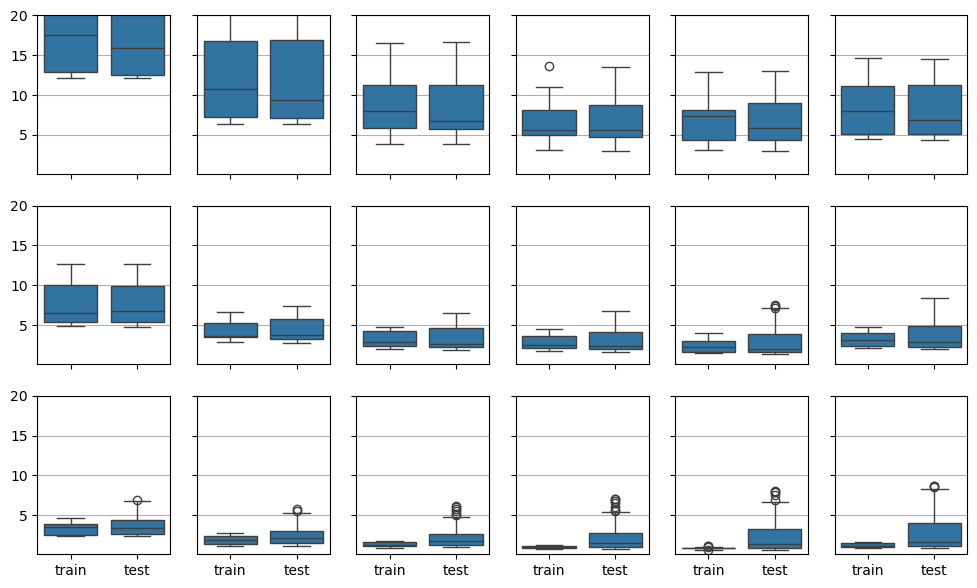

In [12]:
fig, axs = plt.subplots(3, 6, sharex = True, sharey = True, figsize=(12, 7))
my_pal = {"nested\nOpInf": "#00a9b7", "regularized\nOpInf": "#9cadb7"}

for j in range(3):
    for k in range(6):

        axs[j, k].grid(True)
        axs[j, k].grid(True)

        data = pd.DataFrame(100 * relative_error_at_time[j, np.invert(is_test), k], columns = ["train"])
        sns.boxplot(data, log_scale=False, ax=axs[j, k])

        data = pd.DataFrame(100 * relative_error_at_time[j, is_test, k], columns = ["test"])
        sns.boxplot(data, log_scale=False, ax=axs[j, k])

        
        # axs[0, k].set_title(f"r = {n+1}", fontsize=fontsize)

        # # bottom row: final time 1.0
        # data = pd.DataFrame(100 * relative_error_at_time_10[:, [2, 1], n], columns = ["nested\nOpInf", "regularized\nOpInf"])
        # sns.boxplot(data, log_scale=True, ax=axs[1, n], palette=my_pal)

axs[0,0].set_ylim(1e-1, 20)

# axs[0, 0].set_ylabel("relative error \n (t=0.2)", fontsize=fontsize)
# axs[0, 0].set_ylim(1e-3, 1e+2)
# axs[0, 0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])

# axs[1, 0].set_ylabel("relative error \n (t=1.0)", fontsize=fontsize)

# # fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error_over_dimension_trn.png", bbox_inches = "tight")

In [13]:
years_ref = [2030, 2040, 2050]
relative_error_at_time = np.zeros((3, n_para, 3))

k_steps = np.zeros((n_para, 3), dtype=int)
for i in range(n_para):
    grid_t = test_data[i]["grid_t"]
    for k in range(3):
        k_steps[i, k] = np.argmin(np.abs(grid_t-years_ref[k]))
        for j in range(3):
            relative_error_at_time[j, i, k] = error[i, j][k_steps[i, k]]

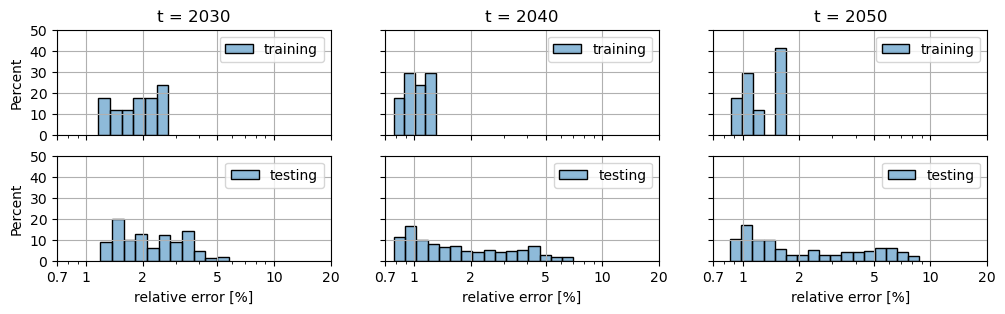

In [32]:
j = 2

fig, axs = plt.subplots(2, 3, sharex = True, sharey = True, figsize=(12, 3))


for k in range(3):

    axs[0,k].grid(True)
    axs[1,k].grid(True)

    data = pd.DataFrame(100 * relative_error_at_time[j, np.invert(is_test), k], columns=["training"])
    sns.histplot(data, log_scale=True, ax=axs[0, k], stat="percent", binwidth=0.06)

    data = pd.DataFrame(100 * relative_error_at_time[j, is_test, k], columns=["testing"])
    sns.histplot(data, log_scale=True, ax=axs[1, k], stat="percent", binwidth=0.06)

    axs[0,k].set_title("t = {}".format(years_ref[k]))
    axs[1,k].set_xlabel("relative error [%]")

    
axs[0,0].set_xlim(0.8, 20)
axs[0,0].set_ylim(0, 50)
axs[0,0].set_yticks([0, 10, 20, 30, 40, 50])
axs[0,0].set_xticks([0.7, 1, 2, 5, 10, 20], [0.7, 1, 2, 5, 10, 20])

# fig.savefig(f"/storage/nicole/Greenland-OpInf/paper/plots/error-threshold{j}.png", bbox_inches = "tight")

In [34]:
sum((100 * relative_error_at_time[j, is_test, 2]) <= 5) / sum(is_test)

np.float64(0.8166666666666667)

In [50]:
error_2D = np.zeros((grid_t_ref.shape[0], n_para))
error_2D_proj = np.zeros((grid_t_ref.shape[0], n_para))

for i in range(n_para):
    f = interp1d(test_data[i]["grid_t"], error[i, 2])
    error_2D[:, i] = f(grid_t_ref)

    yolo = test_data[i]["norm_ortho"] / np.maximum(test_data[i]["norm_ref"], 1)
    f = interp1d(test_data[i]["grid_t"], yolo)
    error_2D_proj[:, i] = f(grid_t_ref)

/tmp/ipykernel_1496502/49812452.py:10: RuntimeWarning: invalid value encountered in divide
  cs2 = axs[1, 0].pcolormesh(X, Y, error_2D / error_2D_proj, cmap=plt.colormaps["viridis"])


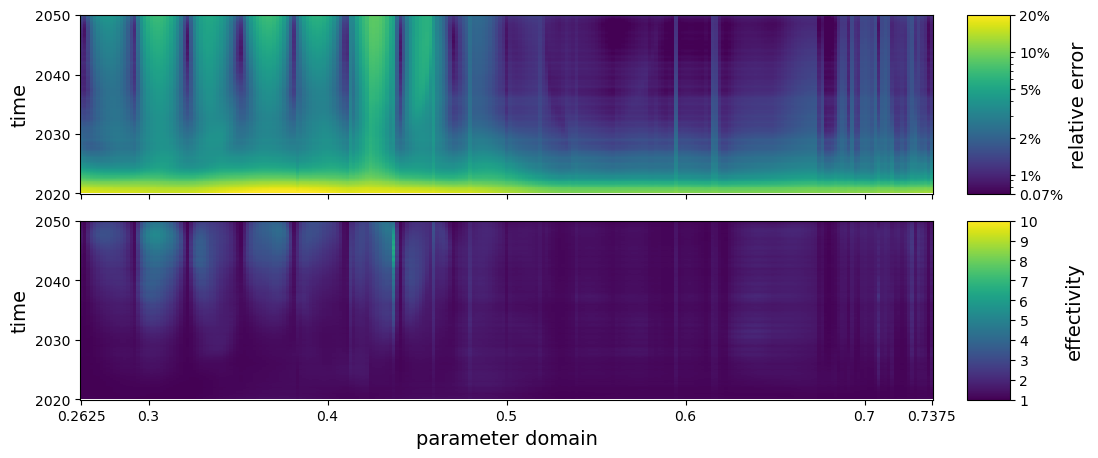

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5), width_ratios=[1, 0.05])
fontsize = 14

a = identifier_orig[list_identifiers][:, 0]
X, Y = np.meshgrid(a, grid_t_ref)

cs = axs[0, 0].pcolormesh(X, Y, 100 * error_2D, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
cs.set_clim(vmin=0.7, vmax=20)

cs2 = axs[1, 0].pcolormesh(X, Y, error_2D / error_2D_proj, cmap=plt.colormaps["viridis"])
cs2.set_clim(vmin=1, vmax=10)

axs[1, 0].set_xlabel("parameter domain", fontsize=fontsize)
axs[1, 0].set_ylabel("time", fontsize=fontsize)
axs[0, 0].set_ylabel("time", fontsize=fontsize)

axs[0,0].set_xticks([0.2625, 0.3, 0.4, 0.5, 0.6, 0.7, 0.7375], [])
axs[1,0].set_xticks([0.2625, 0.3, 0.4, 0.5, 0.6, 0.7, 0.7375], [0.2625, 0.3, 0.4, 0.5, 0.6, 0.7, 0.7375])

cbar = fig.colorbar(cs, cax=axs[0, -1])
cbar.ax.set_yticks([0.7, 1, 2, 5, 10, 20], ["0.07%", "1%", "2%", "5%", "10%", "20%"])
cbar.ax.set_ylabel("relative error", fontsize = fontsize)

cbar = fig.colorbar(cs2, cax=axs[1, -1])
cbar.ax.set_yticks(np.arange(1, 11), np.hstack([np.arange(1, 10), "10     "]))
cbar.ax.set_ylabel("effectivity", fontsize = fontsize)

fig.subplots_adjust(hspace=0.15)
fig.subplots_adjust(wspace=0.15/2)

# fig.savefig(f"/storage/nicole/Greenland-OpInf/paper/plots/error2D_effectivity.png", bbox_inches = "tight")

In [ ]:
please stop here

In [72]:
identifier_orig[256]

array([0.5])

In [73]:
identifier[256]

'00000000'

In [ ]:
VR_vel

In [79]:
io.savemat("/storage/nicole/Greenland-OpInf/paper/data-Fri/modes-vel.mat", {"VR_vel": VR_vel})

In [16]:
sum(is_test)

np.int64(240)

In [17]:
VRq[1].shape

(20455, 12)

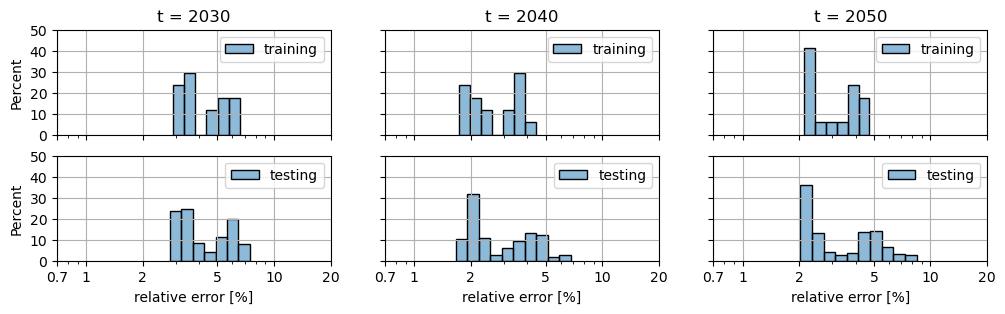

In [ ]:
j = 1

fig, axs = plt.subplots(2, 3, sharex = True, sharey = True, figsize=(12, 3))


for k in range(3):

    axs[0,k].grid(True)
    axs[1,k].grid(True)

    data = pd.DataFrame(100 * relative_error_at_time[j, np.invert(is_test), k], columns=["training"])
    sns.histplot(data, log_scale=True, ax=axs[0, k], stat="percent", binwidth=0.06)

    data = pd.DataFrame(100 * relative_error_at_time[j, is_test, k], columns=["testing"])
    sns.histplot(data, log_scale=True, ax=axs[1, k], stat="percent", binwidth=0.06)

    axs[0,k].set_title("t = {}".format(years_ref[k]))
    axs[1,k].set_xlabel("relative error [%]")

    
axs[0,0].set_xlim(0.8, 20)
axs[0,0].set_ylim(0, 50)
axs[0,0].set_yticks([0, 10, 20, 30, 40, 50])
axs[0,0].set_xticks([0.7, 1, 2, 5, 10, 20], [0.7, 1, 2, 5, 10, 20])

# fig.savefig(f"/storage/nicole/Greenland-OpInf/paper/plots/error-threshold{j}.png", bbox_inches = "tight")

In [19]:
please stop here

SyntaxError: invalid syntax (1680074362.py, line 1)

Below is the cumulative relative error over the 30 simulation years.

In [ ]:
fig, ax = plt.subplots(1,1)

ax.semilogy(identifier_orig[list_identifiers], 100 * error[:, 1], marker = "x")
ax.set_xlabel("parameter")
ax.set_ylabel("relative error [%]")
ax.set_ylim(1e-1, 1e+3)
ax.grid(True)

In this notebook we are primarily interested in the stats:

In [ ]:
time_test = 0
time_train = 0
n_test = np.sum(is_test)
n_train = np.sum(1-is_test)
# ISSM_compute_time = np.zeros(n_para)
speed_up = np.zeros(n_para)

with open(savepath + f"ISSM_compute_time", "rb") as file:
    ISSM_compute_time = pickle.load(file)[0]

for i in range(n_para):
    if is_test[i]:
        time_test += compute_time[i]
    else:
        time_train += compute_time[i]

    # my_identifier = identifier[list_identifiers[i]]
    # filepath = (
    #     load_path_issm
    #     + "/ProjectionRun_SSA_mesh0_name_{}.mat".format(
    #         my_identifier
    #     )
    # )
    # loaded = io.loadmat(filepath)
    # ISSM_compute_time[i] = np.sum(loaded['data_time']) * 2 # times 2 because computed on 2 cores

    speed_up[i] = ISSM_compute_time[i] / compute_time[i]

print(time_test / n_test, time_train / n_train)

# with open(savepath + f"ISSM_compute_time", "wb") as file:
#     pickle.dump([ISSM_compute_time], file)

In [ ]:
np.min(speed_up)

In [ ]:
np.mean(speed_up)

In [ ]:
np.mean(ISSM_compute_time / 60 / 60)

In [ ]:
error_test = 100 * error[is_test, 1] / 30
error_train = 100 * error[np.invert(is_test), 1] / 30

print(f"min / mean / max training error: {np.min(error_train):.3f} / {np.mean(error_train):.3f} / {np.max(error_train):.3f}")
print(f"min / mean / max testing error:  {np.min(error_test):.3f} / {np.mean(error_test):.3f} / {np.max(error_test):.3f}")